# Implied Vol Fit

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the implied vol functionalities in the SDevPy library. In its current state, it uses as example the first model in [[Gurrieri 2010]](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1779463).

Named 'TsSvi1' for "Term-Structure SVI 1", this model is essentially the original SVI model by J. Gatheral at each expiry, but where the SVI parameters are parametric functions of time. It is thus a global model for the implied vol surface, calibrated to all options at once. For more details on the properties of this model, see reference above.

In [1]:
import datetime as dt
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.maths.metrics import rmse
from sdevpy.analytics import black
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.market.yieldcurve import get_yieldcurve
from sdevpy.market.eqforward import get_forward_curves
from sdevpy.volatility.impliedvol.models.tssvi1 import TsSvi1
from sdevpy.volatility.impliedvol.models.tssvi2 import TsSvi2
from sdevpy.volatility.impliedvol.models.logmix import LogMix
from sdevpy.volatility.impliedvol.impliedvol_calib import TsIvCalibrator
from sdevpy.volatility.localvol.dupire_calib import calib_lv_dupire
from sdevpy.volatility.localvol.black_calib import calib_lv_black
from sdevpy.utilities import timegrids
from sdevpy.utilities.timegrids import TimeGridBucket
from sdevpy.utilities.tools import isequal
from sdevpy.utilities import dates as dts
from sdevpy.utilities.algos import upper_bound
from sdevpy.utilities import book as bk
from sdevpy.montecarlo.payoffs.vanillas import make_vanilla_option
from sdevpy.montecarlo.payoffs import cashflows as cfl
from sdevpy.montecarlo.payoffs.basic import Trade, Instrument
from sdevpy.montecarlo.mcpricer import price_book
from sdevpy.pde.pdeschemes import PdeConfig
from sdevpy.pde.forwardpde import calculate_densities


print("SDevPy version: " + sd.__version__)

SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [2]:
name = "ABC"
valdate = dt.datetime(2025, 12, 15)

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]

# Retrieve option data
file = vsurf.data_file(name, valdate)
option_data = vsurf.eqvolsurfacedata_from_file(file)
mkt_data = {'option_data': option_data, 'forward_curve': fwd_curve}
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = option_data.expiries
fwds = fwd_curve.value(expiries)
mkt_strikes = option_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
mkt_vols = option_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(mkt_strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(mkt_strikes[i])}/{len(mkt_vols[i])}")

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5


### Fit Implied Vol Model
In this section we choose and fit an implied vol model, and then display the accuracy of the fit against the market data.

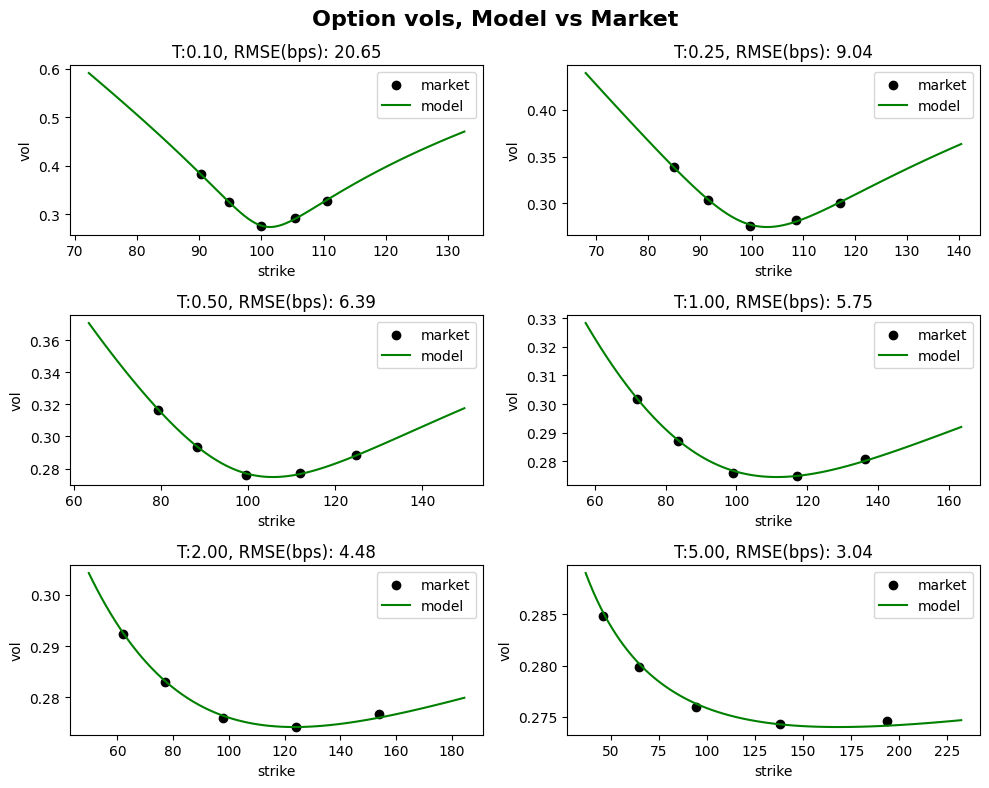

In [3]:
# Initialize model
# iv_surface = LogMix(2)
iv_surface = TsSvi1()

# # Flat on spot with term-structure (compare to BS)
# iv_surface = TsSvi2()
# # v0, vinf, chi, tau_v, alpha, beta, rho0, rhoinf, tau_rho, m0, minf, tau_m, s0, sinf, tau_s
# init_point = [0.32,  0.22, 0.0, 0.7, 0.0, 0.0, 0.0, -0.2, 1.3,  0.001, -0.017,  0.23, 0.000001,
#               2.0, 5.0]
# iv_surface.update_params(init_point)
# iv_surface.base_date = valdate

# iv_surface = LogMix(1)
# init_params = [0.2, 0.2, 0.2, 0.5, 1.0]
# iv_surface.update_params(init_params)
# iv_surface.base_date = valdate

# Calibrate model
calibrator = TsIvCalibrator(iv_surface, {'optimizer': 'SLSQP', 'tol': 1e-6})
calibrator.calibrate(mkt_data)

# Display accuracy of the fit. Estimate model on points and calculate RMSE, plot comparison.
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = timegrids.model_time(valdate, expiries[exp_idx])
        fwd = fwds[exp_idx]
        exp_strikes = mkt_strikes[exp_idx]
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        m_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        m_vols = iv_surface.black_volatility(expiry, m_strikes, fwd)
        ax.scatter(exp_strikes, mkt_vols[exp_idx], label="market", color='black')
        ax.plot(m_strikes, m_vols, label="model", color='green')
        model_vols = iv_surface.black_volatility(expiry, exp_strikes, fwd)
        vol_rmse = rmse(mkt_vols[exp_idx], model_vols)
        ax.set_title(f"T:{expiry:.2f}, RMSE(bps): {10000.0 * vol_rmse:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, Model vs Market', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Black Calibration
Mostly for testing and illustration purposes, we show how to recover the Black calibration results, both for constant and time-dependent vols.

In [4]:
# Flat Black (constant vol)
idx = 3 # Pick index of date to calibrate to
calib_dates = [expiries[idx]]
calib_fwds = np.asarray([fwd_curve.value(expiries[idx])])
calib_strikes = calib_fwds
black_calib = calib_lv_black(iv_surface, valdate, calib_dates, calib_strikes, calib_fwds)
black_lv_flat_obj = black_calib['lv']
print(f"Black LV (Constant): {black_lv_flat_obj.vol}")

# Time-dependent Black (one vol per maturity, at ATM)
calib_dates = expiries
calib_fwds = np.asarray(fwd_curve.value(expiries))
calib_strikes = calib_fwds
black_calib = calib_lv_black(iv_surface, valdate, calib_dates, calib_strikes, calib_fwds)
black_lv_td_obj = black_calib['lv']
print(f"Black LV (Time-Dependent): {black_lv_td_obj.vol_grid}")

Black LV (Constant): 0.27580754427842
Black LV (Time-Dependent): [np.float64(0.2758535943330451), np.float64(0.2760053104352038), np.float64(0.27604146083817777), np.float64(0.2756225947684055), np.float64(0.2750210871220797), np.float64(0.27508353412504133)]


### Local Vol Calibration (Dupire)
Now we use the implied volatility surface calibrated to market data in the previous section to derive the corresponding local volatility using the Dupire method.

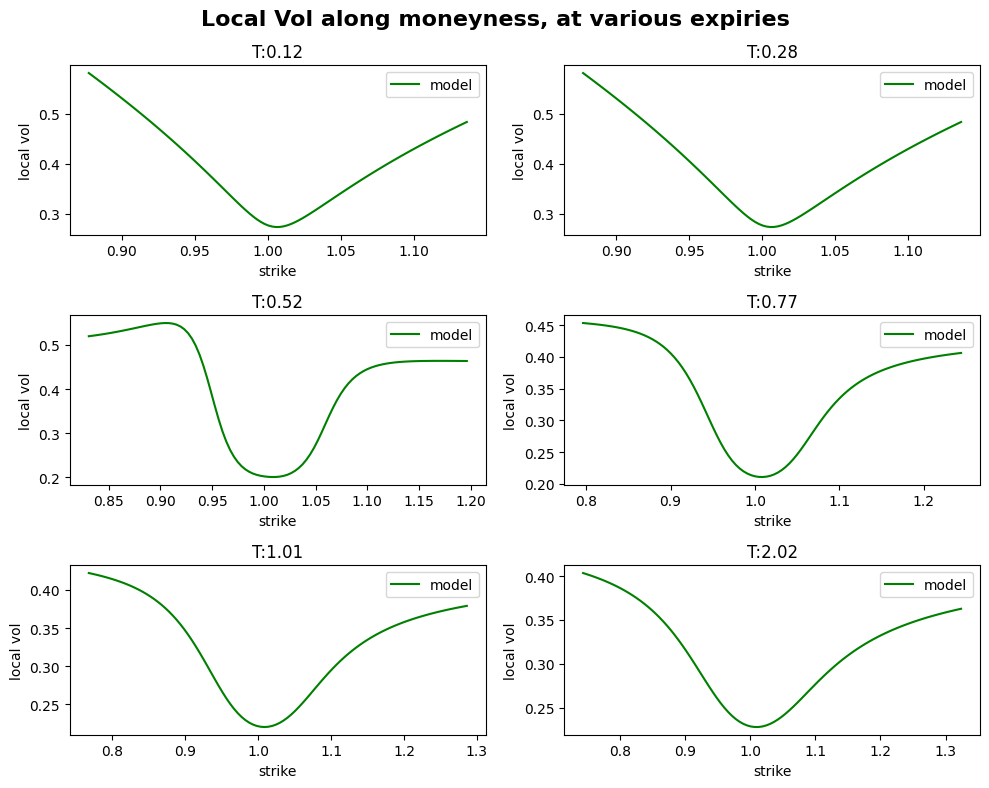

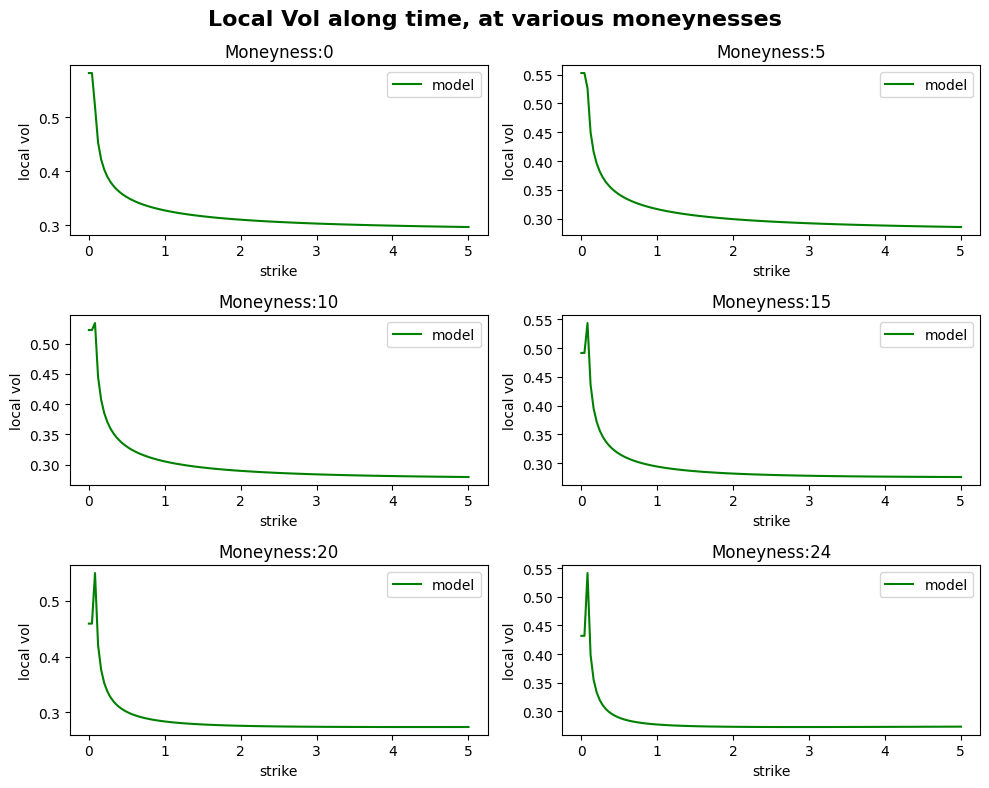

In [5]:
# Granularity
points_per_year = 25
n_strikes = 100
view_times = [0.1, 0.25, 0.5, 0.75, 1.0, 2.0] # Must have len = 6

# Retrieve calibration horizon
tmax = timegrids.model_time(valdate, expiries.max())

# Define time grid by time buckets
time_buckets = []
time_buckets.append(TimeGridBucket(start=0.0, end=0.1, n_points=20))
time_buckets.append(TimeGridBucket(start=0.1, end=0.5, n_points=40))
time_buckets.append(TimeGridBucket(start=0.5, end=1.0, n_points=25))
time_buckets.append(TimeGridBucket(start=1.0, end=10.0, n_points=100))

# Define time grid for BS case
# lv_calib_dates = [valdate]
# lv_calib_dates.extend(expiries)
# lv_calib_times = timegrids.model_time(valdate, lv_calib_dates)
# print(lv_calib_times)

# Launch Dupire calibration
lv_calib = calib_lv_dupire(iv_surface, points_per_year=points_per_year, n_strikes=n_strikes,
                           tmax=tmax)#, time_buckets=time_buckets, low_percent=0.01)#, t_grid=lv_calib_times)
lv_t = lv_calib['t_grid']
lv_moneyness = lv_calib['moneyness']
lv_matrix = lv_calib['lv_matrix']
lv_obj = lv_calib['lv']

# View the LV along the strike at several expiries
t_idx = [upper_bound(lv_t, tp) for tp in view_times]
plot_lv_t = lv_t[t_idx]

n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_lv_t[exp_idx]
        ax.plot(lv_moneyness[exp_idx], lv_matrix[exp_idx], label="model", color='green')
        ax.set_title(f"T:{expiry:.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along moneyness, at various expiries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# View LV along the expiry at several moneynesses
m_idx = [0, 5, 10, 15, 20, 24]
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        k_idx = n_cols * i + j
        k_idx = m_idx[k_idx]
        lv_ = [lv_matrix[tidx][k_idx] for tidx in range(len(lv_t))]
        ax.plot(lv_t, lv_, label="model", color='green')
        ax.set_title(f"Moneyness:{k_idx}")
        ax.set_xlabel('strike')
        ax.set_ylabel('local vol')
        ax.legend()

fig.suptitle('Local Vol along time, at various moneynesses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Calculate Closed-Form prices
Now that we have an implied vol model, we can calculate option prices at any maturities and strikes. We choose a set and calculate the closed-form prices and implied vols, i.e. those implied by the calibrated model. Then we will proceed to calibrate the local vol and check how close the numerical prices (MC and PDE) are to the closed-form.

We define 6 expiries to inspect the model (they may or may not be the market's). Then we specify a range of
strikes within certain reasonable percentiles of the distribution, and finally we calculate the closed-form prices (i.e. the prices from the calibrated IV model).

In [6]:
view_user_expiries = True
n_strikes = 10
lw_p = 0.05 # Low percentile strike
up_p = 1.0 - lw_p # High percentile strike

# Define 6 expiries to inspect the model (do not have to be the market's)
if view_user_expiries:
    plot_tenors = ['1m', '3m', '6m', '9m', '1y', '2y']
    plot_dates = [dts.advance(valdate, tenor) for tenor in plot_tenors]
else:
    plot_dates = expiries

plot_times = timegrids.model_time(valdate, plot_dates)

# Calculate observation strikes and closed-form straddle prices/IVs
percentiles = np.linspace(lw_p, up_p, n_strikes)
n_quantiles = norm.ppf(percentiles)
plot_fwds, plot_strikes, plot_cf_prices, plot_cf_ivs = [], [], [], []
for date, time in zip(plot_dates, plot_times, strict=True):
    fwd = fwd_curve.value(date)
    atm = iv_surface.black_volatility(time, fwd, fwd)
    stdev = atm * np.sqrt(time)
    strikes = fwd * np.exp(-0.5 * stdev * stdev + stdev * n_quantiles)
    plot_fwds.append(fwd)
    plot_strikes.append(strikes)
    call = iv_surface.forward_price(time, strikes, True, fwd)
    put = iv_surface.forward_price(time, strikes, False, fwd)
    plot_cf_prices.append(call + put)
    plot_cf_ivs.append(iv_surface.black_volatility(time, strikes, fwd))

### Compare MC prices to IV model

In [7]:
def analyse_numerical_prices(num_prices):
    """ Small helper to calculate implied vols from numerical prices and RMSEs to closed-form """
    num_ivs, rmses = [], []
    for i in range(len(plot_dates)):
        expiry = plot_times[i]
        fwd = plot_fwds[i]
        exp_strikes = plot_strikes[i]
        num_price = num_prices[i]
        num_iv = []
        for j in range(len(exp_strikes)):
            strike = exp_strikes[j]
            try:
                call_price = (num_price[j] - strike + fwd) / 2.0 # Call from straddle
                iv = black.implied_vol(expiry, strike, True, fwd, call_price)
            except Exception:
                iv = np.nan
            num_iv.append(iv)

        vol_rmse = rmse(num_iv, plot_cf_ivs[i])
        num_ivs.append(num_iv)
        rmses.append(vol_rmse)

    return num_ivs, np.asarray(rmses)

Runtime(Generate spot paths): 1.5s
Runtime(Interpolate to event grid): 0.0s
Runtime(Payoff calculation): 0.0s


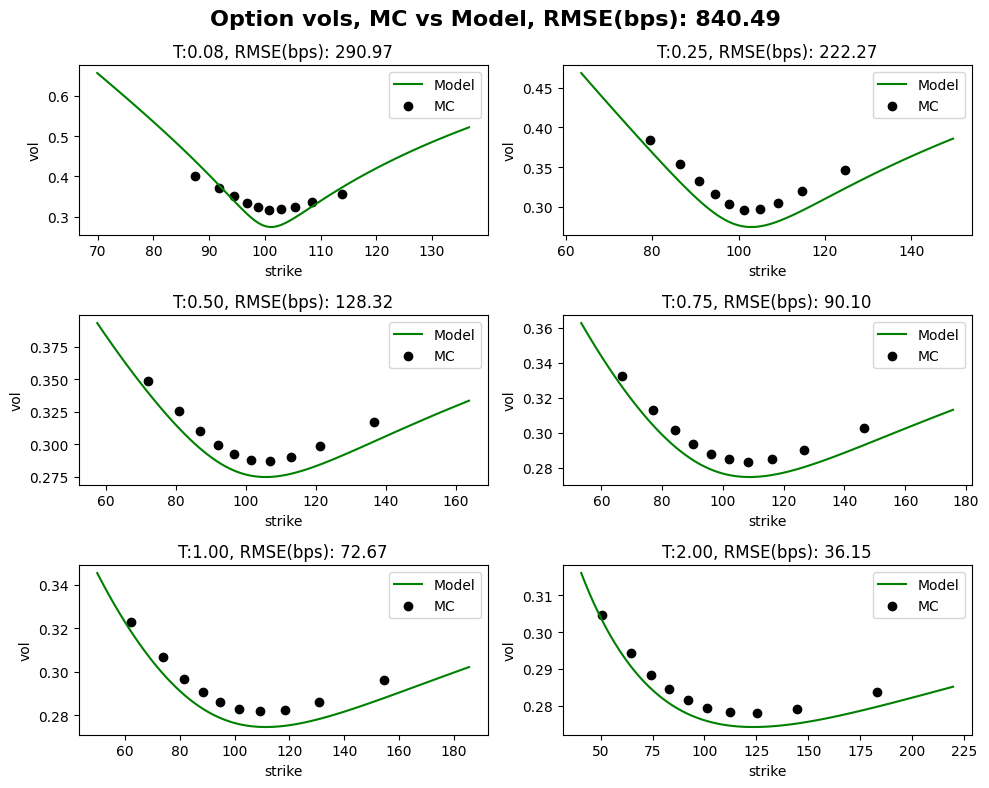

In [ ]:
n_paths = 20000
n_steps = 250

# Choose model to use in numerical methods (both MC and PDE)
# lv_map = {name: black_lv_flat_obj}
# lv_map = {name: black_lv_td_obj}
lv_map = {name: lv_obj}

# Create portfolio
option_type = 'Straddle'
trades = []
for exp_idx, expiry in enumerate(plot_dates):
    exp_strikes = plot_strikes[exp_idx]
    for strike in exp_strikes:
        index = make_vanilla_option(name, strike, option_type, expiry)
        cf = cfl.Cashflow(index, expiry)
        trades.append(Trade(Instrument(cashflow_legs=[[cf]])))

# Create book
book = bk.Book()
book.add_trades(trades)

# Calculate MC prices (discounted)
sim_prices = price_book(valdate, book, constr_type='brownianbridge', rng_type='sobol',
                        n_paths=n_paths, n_timesteps=n_steps, lv_map=lv_map)
sim_prices = sim_prices['pv']

# Calculate forward prices and reformat container (per expiry)
disc_curve = get_yieldcurve(book.csa_curve_id, valdate)
mc_prices = []
count = 0
for i in range(len(plot_dates)):
    expiry = plot_times[i]
    fwd = plot_fwds[i]
    disc = disc_curve.discount(plot_dates[i]) # To capitalize MC prices
    mc_price = []
    for _ in range(len(plot_strikes[i])):
        disc_price = sim_prices[count]
        mc_price.append(disc_price / disc)
        count += 1

    mc_prices.append(mc_price)

# Calculate implied vols and accuracy
mc_ivs, mc_rmses = analyse_numerical_prices(mc_prices)
mc_rmse = mc_rmses.sum()

## Plot ##
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_dates[exp_idx]
        t = plot_times[exp_idx]
        fwd = plot_fwds[exp_idx]
        exp_strikes = plot_strikes[exp_idx]

        # Generate 'continuous' plot for closed-form
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        cf_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        cf_vols = iv_surface.black_volatility(t, cf_strikes, fwd)
        ax.plot(cf_strikes, cf_vols, label="CF", color='green')

        # Scatter for MC IVs
        ax.scatter(exp_strikes, mc_ivs[exp_idx], label="MC", color='black')

        ax.set_title(f"T:{t:.2f}, RMSE(bps): {10000.0 * mc_rmses[exp_idx]:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle(f'Option vols, MC vs CF, RMSE(bps): {10000.0 * mc_rmse:,.2f}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Compare PDE prices to IV model

Time steps: 200
Spot steps: 250
First mesh vol: 27.59%
Mass: 0.990856
Mass: 0.997052
Mass: 0.999281
Mass: 0.999716
Mass: 0.999850
Mass: 0.999892


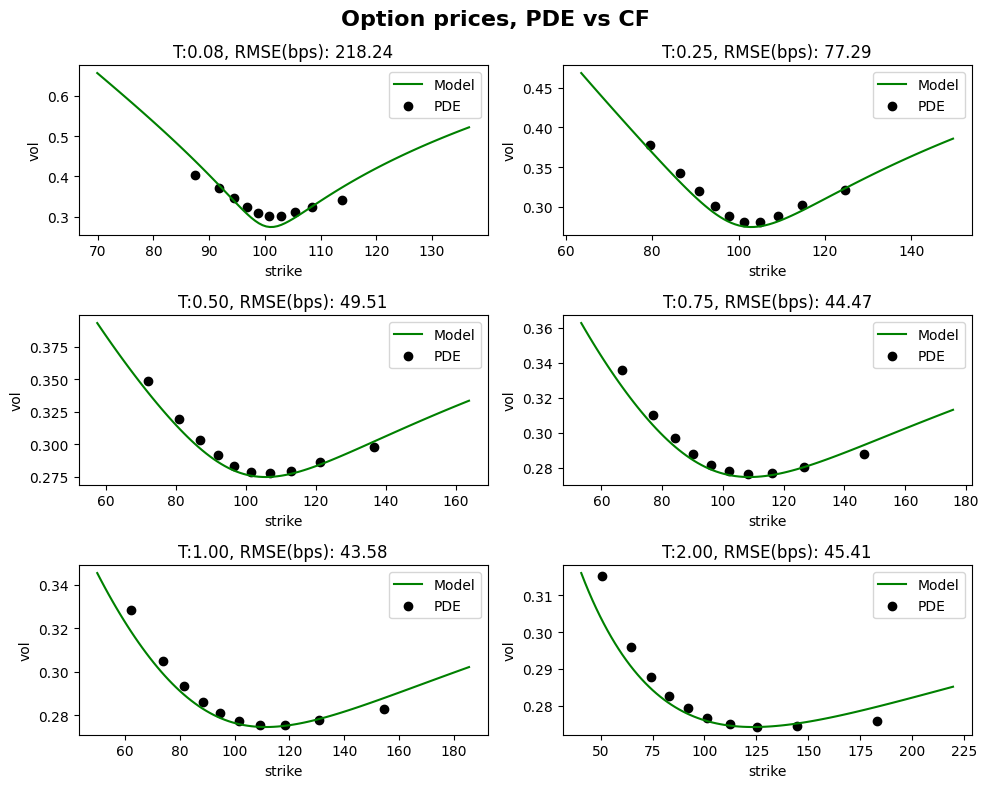

In [ ]:
n_timesteps, n_meshes, scheme = 200, 250, 'rannacher'

# PDE config
mesh_vol = iv_surface.black_volatility(plot_times[0], 1.0, 1.0)
pde_config = PdeConfig(n_timesteps=n_timesteps, n_meshes=n_meshes, mesh_vol=mesh_vol, scheme=scheme,
                        rescale_x=True, rescale_p=True, shift_forward=False,
                        iv_surface=iv_surface)
print(f"Time steps: {pde_config.n_timesteps}")
print(f"Spot steps: {pde_config.n_meshes}")
print(f"First mesh vol: {mesh_vol*100:.2f}%")

# Run PDE to calculate densities at each maturity
lv_func = lv_map[name].value
density_reports = calculate_densities(plot_times, lv_func, pde_config)

# Calculate PDE prices (forward)
pde_prices = []
for r_idx, density_report in enumerate(density_reports):
    dens_mty = density_report['end_time']
    x = density_report['x_grid']
    p = density_report['p_grid']
    fwd = plot_fwds[r_idx]

    # Check timing consistency
    if not isequal(dens_mty, plot_times[r_idx]):
        raise ValueError(f"Inconsistent times between closed-form and densities at density time {dens_mty}")

     # Calculate PDE prices
    s = fwd * np.exp(x)
    strikes = plot_strikes[r_idx]
    pde_price = []
    for k in strikes:
        payoff = np.maximum(s - k, 0.0) + np.maximum(k - s, 0.0)
        weighted_payoff = payoff * p
        pde_price.append(np.trapezoid(weighted_payoff, x))

    pde_prices.append(np.asarray(pde_price))

# Calculate implied vols and accuracy
pde_ivs, pde_rmses = analyse_numerical_prices(pde_prices)
pde_rmse = pde_rmses.sum()

## Plot ##
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = plot_dates[exp_idx]
        t = plot_times[exp_idx]
        fwd = plot_fwds[exp_idx]
        exp_strikes = plot_strikes[exp_idx]

        # Generate 'continuous' plot for closed-form
        min_k, max_k = exp_strikes[0], exp_strikes[-1]
        cf_strikes = np.linspace(0.8 * min_k, 1.2 * max_k, 100)
        cf_vols = iv_surface.black_volatility(t, cf_strikes, fwd)
        ax.plot(cf_strikes, cf_vols, label="CF", color='green')

        # Scatter for MC IVs
        ax.scatter(exp_strikes, pde_ivs[exp_idx], label="PDE", color='black')

        ax.set_title(f"T:{t:.2f}, RMSE(bps): {10000.0 * pde_rmses[exp_idx]:,.2f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('vol')
        ax.legend()

fig.suptitle('Option vols, PDE vs CF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# print(f"MC prices: {mc_prices}")
# print(f"MC IVs: {mc_ivs}")
# print(f"PDE prices: {pde_prices}")
# print(f"PDE IVs: {pde_ivs}")